In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from pytorch_metric_learning import losses
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

dataset = datasets.EuroSAT(root=".", download=True, transform=transform)
train = int(0.8 * len(dataset))
test = len(dataset) - train
train_ds, test_ds = torch.utils.data.random_split(dataset, [train, test])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
emb_size = 128
model.fc = nn.Linear(model.fc.in_features, emb_size)
model.to(device)

/home/a.stolyarov/Paralellki/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/a.stolyarov/Paralellki/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [53]:
criterion = losses.ArcFaceLoss(num_classes=10, embedding_size=emb_size, margin=0.5, scale=30).to(device)

optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': criterion.parameters()}], 
    lr=1e-4)

In [54]:
loss_history = []

def train(epochs=3):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            embeddings = model(images)
            loss = criterion(embeddings, labels)
            
            loss.backward()
            optimizer.step()
            
            loss_history.append(loss.item())
            epoch_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")
train(epochs=3)

Epoch 1 | Batch 0 | Loss: 3.5163
Epoch 1 | Batch 100 | Loss: 0.5160
Epoch 1 | Batch 200 | Loss: 0.2476
Epoch 1 | Batch 300 | Loss: 0.4440
Epoch 1 | Batch 400 | Loss: 0.1228
Epoch 1 | Batch 500 | Loss: 0.1499
Epoch 1 | Batch 600 | Loss: 0.0448
Epoch 2 | Batch 0 | Loss: 0.2023
Epoch 2 | Batch 100 | Loss: 0.1437
Epoch 2 | Batch 200 | Loss: 0.1571
Epoch 2 | Batch 300 | Loss: 0.0483
Epoch 2 | Batch 400 | Loss: 0.0109
Epoch 2 | Batch 500 | Loss: 0.2608
Epoch 2 | Batch 600 | Loss: 0.1186
Epoch 3 | Batch 0 | Loss: 0.0027
Epoch 3 | Batch 100 | Loss: 0.0236
Epoch 3 | Batch 200 | Loss: 0.0199
Epoch 3 | Batch 300 | Loss: 0.3463
Epoch 3 | Batch 400 | Loss: 0.0670
Epoch 3 | Batch 500 | Loss: 0.0112
Epoch 3 | Batch 600 | Loss: 0.0072


In [ ]:
import torch.nn.functional as F
import numpy as np

def get_data_for_tsne(model, arcface_layer, loader, device):
    model.eval()
    arcface_layer.eval() # Веса центроидов лежат здесь
    
    embeddings = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # Получаем признаки из основной модели (до ArcFace слоя)
            features = model(images)
            # В ArcFace эмбеддинги обычно нормализованы
            features = F.normalize(features, dim=1)
            
            embeddings.append(features.cpu())
            labels_list.append(labels)

    embeddings = torch.cat(embeddings).numpy()
    labels_list = torch.cat(labels_list).numpy()

    # Извлекаем центроиды (веса слоя ArcFace) и тоже нормализуем
    with torch.no_grad():
        centroids = F.normalize(arcface_layer.weight, dim=1).cpu().numpy()
    
    return embeddings, labels_list, centroids

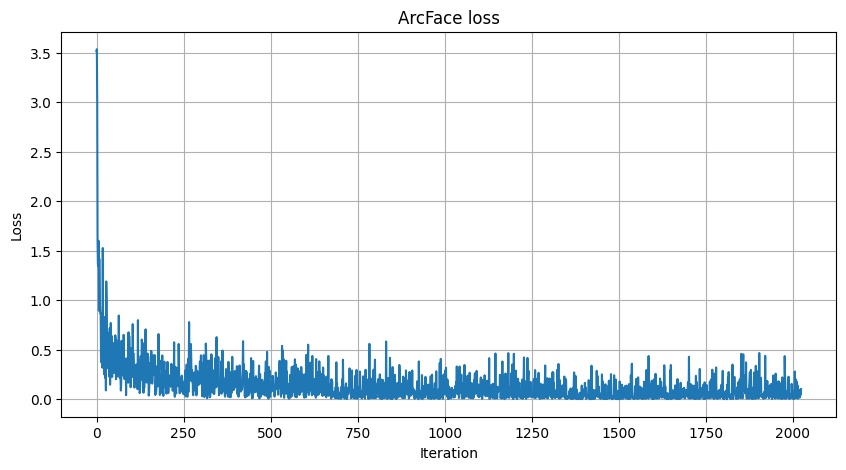

In [56]:
def plot_loss():
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title("ArcFace loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_loss()

def visualize_tsne_with_centroids(embeddings, labels, centroids):
    n_codes = embeddings.shape[0]
    n_classes = centroids.shape[0]
    
    # Объединяем данные для t-SNE
    all_data = np.vstack([embeddings, centroids])
    
    tsne = TSNE(n_components=2, random_state=42)
    X_transformed = tsne.fit_transform(all_data)
    
    # Разделяем обратно
    X_emb = X_transformed[:n_codes]
    X_centroids = X_transformed[n_codes:]
    
    plt.figure(figsize=(10, 8))
    
    # Рисуем обычные объекты (прозрачные точки)
    scatter = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, 
                         cmap='tab10', alpha=0.3, s=10, label='Data points')
    
    # Рисуем центроиды (крупные кресты или точки с обводкой)
    plt.scatter(X_centroids[:, 0], X_centroids[:, 1], c=range(n_classes), 
                cmap='tab10', marker='X', s=200, edgecolors='black', linewidths=1.5,
                label='Centroids')
    
    plt.legend()
    plt.title("t-SNE ArcFace: Embeddings and Class Centroids")
    plt.show()

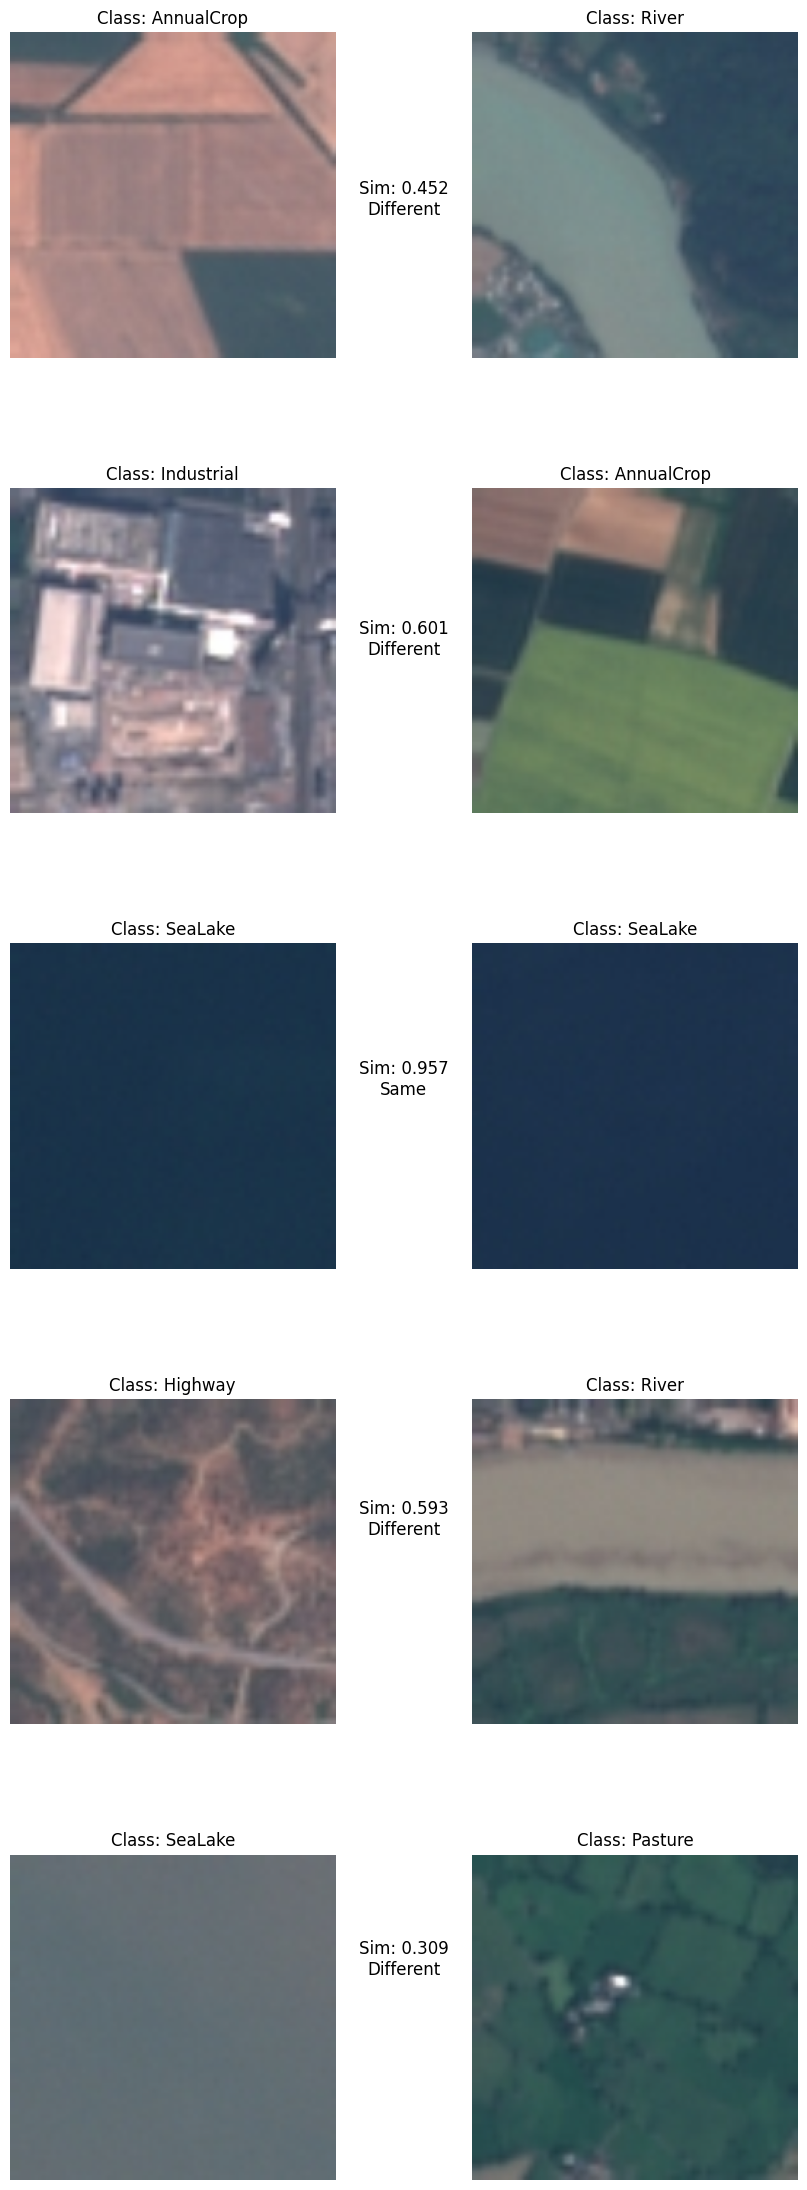

In [57]:
def show_pairs():
    model.eval()
    fig, axes = plt.subplots(5, 2, figsize=(10, 22))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    threshold = 0.7

    with torch.no_grad():
        for i in range(5):
            idx1, idx2 = np.random.randint(0, len(test_ds), 2)
            img1, label1 = test_ds[idx1]
            img2, label2 = test_ds[idx2]
            
            emb1 = model(img1.unsqueeze(0).to(device))
            emb2 = model(img2.unsqueeze(0).to(device))
            
            sim = torch.nn.functional.cosine_similarity(emb1, emb2).item()
            
            verdict = "Same" if sim > threshold else "Different"
            
            for j, (img, lbl, ax) in enumerate(zip([img1, img2], [label1, label2], axes[i])):
                im = img.permute(1, 2, 0).numpy() * std + mean
                ax.imshow(np.clip(im, 0, 1))
                ax.set_title(f"Class: {dataset.classes[lbl]}")
                ax.axis('off')
                        
            fig.text(0.5, 1.0 - (i + 0.5) / 5, f"Sim: {sim:.3f}\n{verdict}", ha = 'center', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()
show_pairs()